🏠 Overall R² Score: 0.6341 (1.0 is perfect)
📉 Mean Squared Error: 2806426667.25
📈 RMSE: 52975.72


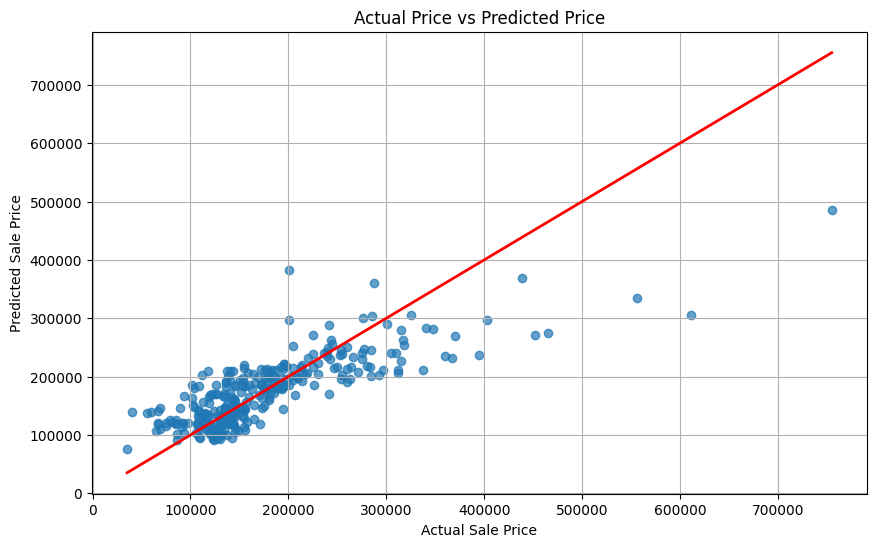


🏡 Prediction for House:
Living Area: 1000.0 sq ft
Bedrooms: 3
Bathrooms: 3
Estimated Price: $166,366


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load Dataset
df = pd.read_csv("train.csv")   # Kaggle House Prices dataset

# Select Features and Target
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

# Remove missing values if any
data = pd.concat([X, y], axis=1).dropna()

X = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = data['SalePrice']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"🏠 Overall R² Score: {r2:.4f} (1.0 is perfect)")
print(f"📉 Mean Squared Error: {mse:.2f}")
print(f"📈 RMSE: {rmse:.2f}")

# Graph: Actual vs Predicted
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.grid(True)
plt.show()

# Custom Prediction Function
def predict_house_price(area, bedrooms, bathrooms):
    prediction = model.predict([[area, bedrooms, bathrooms]])[0]
    
    print(f"\n🏡 Prediction for House:")
    print(f"Living Area: {area} sq ft")
    print(f"Bedrooms: {bedrooms}")
    print(f"Bathrooms: {bathrooms}")
    print(f"Estimated Price: ${prediction:,.0f}")

# Try it yourself!
try:
    area = float(input("Enter Living Area (sq ft): "))
    bedrooms = int(input("Enter Number of Bedrooms: "))
    bathrooms = int(input("Enter Number of Bathrooms: "))

    predict_house_price(area, bedrooms, bathrooms)

except ValueError:
    print("❌ Invalid input! Please enter numbers only.")